In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
# Question 1: Download and upload the Airplane Crashes Dataset from Kaggle.

path = kagglehub.dataset_download("saurograndi/airplane-crashes-since-1908")
df = pd.read_csv("/kaggle/input/airplane-crashes-since-1908/Airplane_Crashes_and_Fatalities_Since_1908.csv")



Using Colab cache for faster access to the 'airplane-crashes-since-1908' dataset.


In [ ]:
# Question 2: Determine the number of rows and columns in the dataset
print(df.shape)

(5268, 13)


In [ ]:
# Question 3: Display the last 75 rows in the dataset.
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
# Question 4: Each column except the first one has some missing data. For each column, name
# the most appropriate method for treating the missing data. Justify your choices

df.columns.tolist()
#These are the columns: ['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Aboard', 'Fatalities', 'Ground', 'Summary']

# For numerical data in columns like Aboard, we can generate an average and put it in the empty slots
# For Fatalities we can assume that the number of people aboard will be equal to the number of fatalities.
# cn/in Drop the column entirely
# For summary we drop the column
# For Ground, since most of the data is 0.0 we can apply an average value
# For Route, Type, Time, Location and Registration we fill the missing values with 'Unknown' as for each of them they are highly unique to each flight.
# For Flight# drop the column since most of them are the same (NaN)



['Date',
 'Time',
 'Location',
 'Operator',
 'Flight #',
 'Route',
 'Type',
 'Registration',
 'cn/In',
 'Aboard',
 'Fatalities',
 'Ground',
 'Summary']

In [ ]:
# Question 6: Create a new dataframe from the raw/uncleaned data called
#‘fatality_locations’ with the following columns: ‘Date’,
#‘Location’, ‘Aboard’, ‘Fatalities’.

fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']]
fatality_locations

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0
...,...,...,...,...
5263,05/20/2009,"Near Madiun, Indonesia",112.0,98.0
5264,05/26/2009,"Near Isiro, DemocratiRepubliCongo",4.0,4.0
5265,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",228.0,228.0
5266,06/07/2009,"Near Port Hope Simpson, Newfoundland, Canada",1.0,1.0


In [ ]:
# Question 6: Determine the date of the highest number of recorded fatalities from this new
# dataframe.

max_fatalities = fatality_locations['Fatalities'].max()
fatality_locations.query("Fatalities == @max_fatalities")['Date']

,Date
2963,03/27/1977


In [ ]:
# Question 7: Compare the number of passengers aboard to the number of fatalities per crash. Are
# there any recorded crashes where there were no fatalities? If so, how many?

no_fatalities = fatality_locations[['Aboard', 'Fatalities']].query("Fatalities == 0")
len(no_fatalities)

58

In [ ]:
# Question 8: In the ‘fatality_locations’ dataframe, the location column has
# data items represented as ‘Region, U.S. State/Country’. Split this column to
# have two columns of regions and states/countries.

fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)
fatality_locations.head()

/tmp/ipykernel_3123/1291485981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)


,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [ ]:
# Question 9: Order the dataframe by the number of fatalities from highest to
# lowest and select the first 100.

fatality_locations.sort_values(by="Fatalities").head(100)

,Date,Location,Aboard,Fatalities,Region,State/Country
5245,01/15/2009,"New York, New York",155.0,0.0,New York,New York
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0,Bartlesville,Oklahoma
1443,10/16/1956,Over the PacifiOcean,31.0,0.0,Over the PacifiOcean,None
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0,Ishikawa City,"Ryukyu Island, Okinawa"
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0,Boston,Massachusetts
...,...,...,...,...,...,...
119,08/22/1927,"Sevenoaks, England",11.0,1.0,Sevenoaks,England
117,05/02/1927,"Algiers, Algeria",3.0,1.0,Algiers,Algeria
5172,09/24/2007,"Malemba Nkulu, DR Congo",6.0,1.0,Malemba Nkulu,DR Congo
146,06/22/1928,"Lebo, Kansas",1.0,1.0,Lebo,Kansas


Using pandas: 



<Axes: ylabel='Fatalities'>

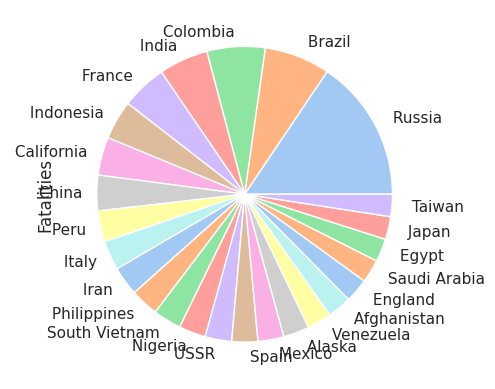

In [ ]:
# Question 10: Generate a pie chart that shows the distribution of the top 25
# number of fatalities per country/U.S. State. [Hint: charts can be generated
# from the seaborn library]

print("Using pandas: \n")
fatality_locations.groupby('State/Country')['Fatalities'].sum().sort_values(ascending=False).head(25).plot(kind='pie')


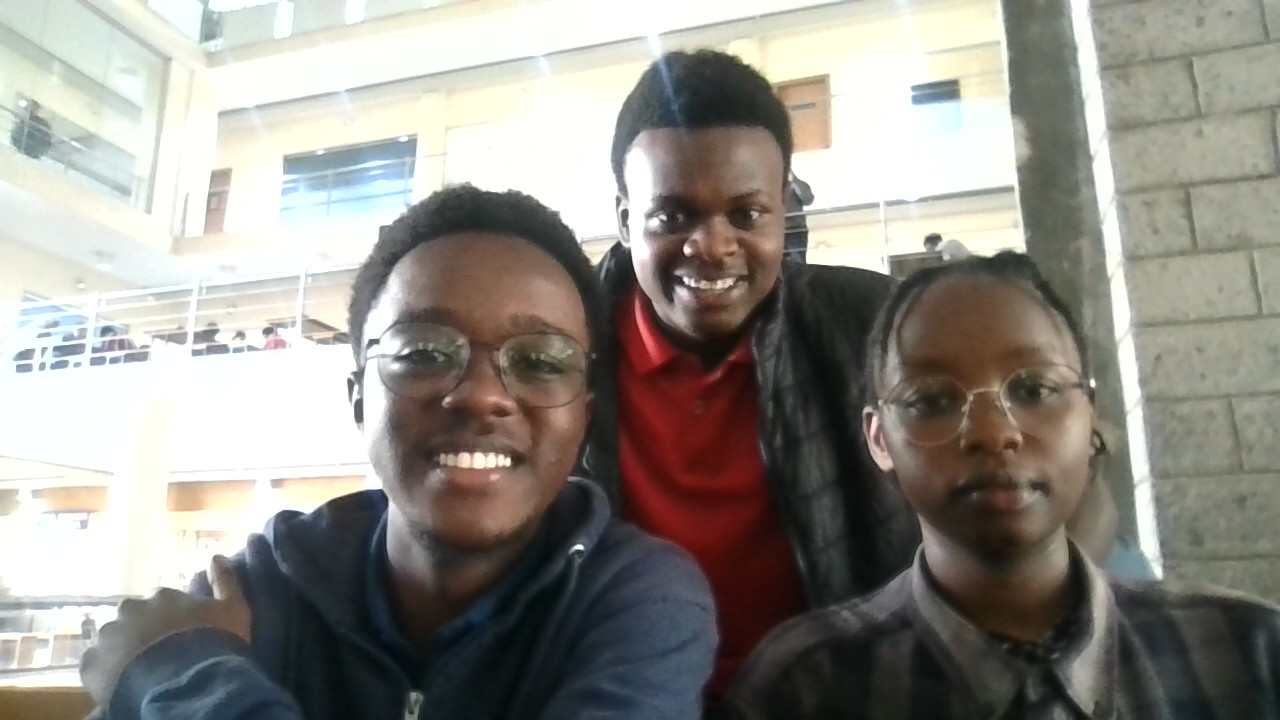